In [4]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## import tensorflow

In [5]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


## Load dataset

In [8]:
df=pd.read_csv('cleaned_data.csv')
df.head()

,label,text
0,0,conoco big cowboy darren sure help know else a...
1,0,feb 01 prod sale teco gas processing sale deal...
2,0,california energy crisis california  power cr...
3,0,nom actual volume april 23 rd agree eileen pon...
4,0,eastrans nomination changes effective 8 2 00 p...


## Tokenization and padding

In [14]:
X=df['text']
y=df['label']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,test_size=0.2
)

tokenizer=Tokenizer()
# Prevent float/NaN values from causing `.lower()` errors during tokenization
X_train = X_train.map(lambda x: str(x).lower())
X_test = X_test.map(lambda x: str(x).lower())

tokenizer.fit_on_texts(X_train)

train_sequence=tokenizer.texts_to_sequences(X_train)
test_sequence = tokenizer.texts_to_sequences(X_test)

max_len=100

train_sequence=pad_sequences(train_sequence,maxlen=max_len,padding='post',truncating="post")
test_sequence=pad_sequences(test_sequence,maxlen=max_len,padding='post',truncating="post")

y_train=(y_train=='spam').astype(int)
y_test=(y_test=='spam').astype(int)

## Define the model

In [15]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 32)        │     1,274,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,278,625 (4.88 MB)

 Trainable params: 1,278,625 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

## Train model

In [16]:
es=EarlyStopping(patience=3,monitor='val_accuracy',restore_best_weights=True)
lr=ReduceLROnPlateau(patience=2,monitor='val_loss',factor=0.5,verbose=False)


history=model.fit(
    train_sequence,y_train,
    validation_data=(test_sequence,y_test),
    epochs=20,
    batch_size=32,
    callbacks=[lr,es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.9962 - loss: 0.2289 - val_accuracy: 1.0000 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 6.2604e-04 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 1.0000 - loss: 5.0796e-04 - val_accuracy: 1.0000 - val_loss: 3.5960e-04 - learning_rate: 0.0010


## Evaluate Model

In [17]:
test_loss,test_accuracy=model.evaluate(test_sequence,y_test)
print("Test loss",test_loss)
print("Test Accuracy:",test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 1.0000 - loss: 0.0082
Test loss 0.008192794397473335
Test Accuracy: 1.0


## Check history

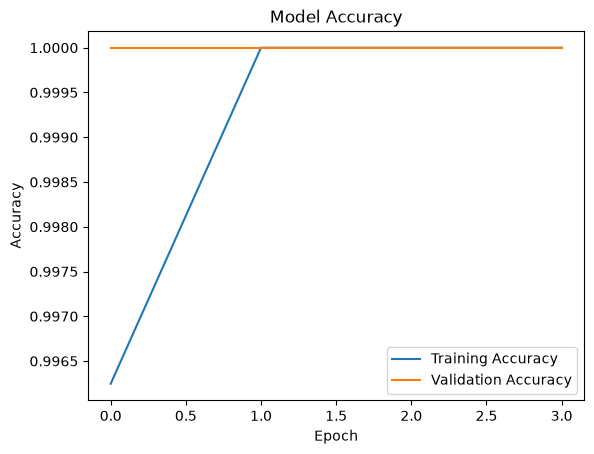

In [18]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()